# 🌊 Terrain Analysis Pipeline - Complete Demonstration

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue.svg)](https://www.python.org/)
[![University](https://img.shields.io/badge/University%20of%20Chicago-MS%20Applied%20Data%20Science-800000.svg)](https://www.uchicago.edu/)

## Overview

This notebook demonstrates the complete **Flood Risk Rating Pipeline** that uses high-resolution LiDAR data to assess property-level flood susceptibility based on micro-topography. The pipeline:

- 🗺️ Downloads 1-meter resolution DEMs from USGS 3DEP
- 🏠 Performs building-aware property localization using OpenStreetMap
- 📊 Computes multi-scale terrain metrics (elevation, slope, flow convergence)
- ⚠️ Generates a physics-based terrain risk score (0-1 scale)
- 📈 Creates rich visualizations and natural language reports

## 1. Environment Setup & Imports

First, we'll set up the environment and import all necessary modules from our custom elevation analysis package.

In [1]:
# Standard library imports
import os
import sys
import json
import warnings
from pathlib import Path

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML, IFrame, Markdown

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Add project source to path
PROJECT_ROOT = Path.cwd().parent  # Adjust based on notebook location
SRC_PATH = PROJECT_ROOT / 'src'
sys.path.insert(0, str(SRC_PATH))

print(f"✅ Environment configured")
print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📦 Source path: {SRC_PATH}")

✅ Environment configured
📁 Project root: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests
📦 Source path: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/src


In [3]:
# Import the main pipeline module
from elevation.run_final_pipeline import PipelineConfig, run_pipeline
from elevation.helpers import compute_global_composite_risk_map


print("✅ Pipeline modules imported successfully")

✅ Pipeline modules imported successfully


## 2. Configuration

Configure the pipeline with an example location. We'll analyze a property in Gainesville, Florida, which has interesting terrain features.

In [5]:
# Create pipeline configuration
config = PipelineConfig()

# 📍 Example location: Gainesville, FL
# You can replace with any US address or coordinates
config.lat = 29.657564
config.lon = -82.320392

# Analysis parameters (all customizable)
config.aoi_radius_m = 100.0          # Area of Interest radius
config.reference_radius_m = 500.0    # Reference area for comparison
config.dem_resolution_m = 1.0        # DEM resolution in meters

# Ring analysis radii for multi-scale metrics
config.ring_metrics_radii = [50.0, 100.0, 200.0, 300.0, 500.0]

# Terrain classification thresholds
config.slope_low_threshold = 2.0     # Degrees - below this is "flat"
config.slope_mod_threshold = 5.0     # Degrees - above this is "steep"

# Output configuration
config.output_dir = "./outputs/demo_run"
config.output_format = "both"        # Save as both CSV and Parquet
config.generate_narrative = True     # Generate text explanation
config.save_3d = True                # Create 3D visualizations
config.verbose = True                # Show progress messages

# Display configuration summary
display(Markdown("### 📋 Pipeline Configuration"))
print(f"Location: {config.lat:.6f}, {config.lon:.6f}")
print(f"AOI Radius: {config.aoi_radius_m}m")
print(f"Ring Metrics: {config.ring_metrics_radii}")
print(f"Output Directory: {config.output_dir}")

### 📋 Pipeline Configuration

Location: 29.657564, -82.320392
AOI Radius: 100.0m
Ring Metrics: [50.0, 100.0, 200.0, 300.0, 500.0]
Output Directory: ./outputs/demo_run


## 3. Execute Pipeline

Run the complete terrain analysis pipeline. This will:
1. Geocode the location and find the building
2. Download LiDAR data from USGS 3DEP
3. Generate high-resolution DEMs
4. Compute terrain metrics
5. Calculate risk scores
6. Generate visualizations

In [6]:
# Execute the pipeline
print("🚀 Starting terrain analysis pipeline...\n")
print("="*80)

try:
    results = run_pipeline(config)
    print("\n" + "="*80)
    print("✅ Pipeline completed successfully!")
except Exception as e:
    print(f"❌ Pipeline failed: {e}")
    raise

🚀 Starting terrain analysis pipeline...

📁 Output directory: ./outputs/demo_run
📍 Radius: 100.0m
TERRAIN ANALYSIS PIPELINE - AOI RADIUS: 100.0m
Target location: 29.657564, -82.320392
Output directory: ./outputs/demo_run

STEP 1: LIDAR DATASET DISCOVERY
Dataset: FL_Peninsular_FDEM_Alachua_2018

STEP 2: DEM GENERATION
DEM specifications:
  - 500m reference: 1.0m resolution
  - 100.0m user: 1.0m resolution
Generated 2 DEM

STEP 3: LOADING DEM & BUILDING MASKS
User DEM (100.0m): (200, 200)
Reference DEM (500m): (1000, 1000)
DEM shape: (1000, 1000)
Primary mask (100.0m): 31428 pixels

STEP 4: FETCHING OSM BUILDING

STEP 5: COMPUTING TERRAIN DERIVATIVES
✓ Computed slope, aspect, curvature

STEP 6: ESTIMATING HOUSE ELEVATION
House elevation: 51.71 m (method: median_IQRtrim_k1.8)

STEP 7: TERRAIN CLASSIFICATION
✓ Terrain classified

STEP 8: GENERATING VISUALIZATIONS
✓ figure1_elevation.png
✓ figure2_slope.png
✓ figure3_aspect.png
✓ figure4_terrain_and_hist.png
[3D] DEM user: dem_100m_dtm.tif
[

## 4. Key Results Summary

Display the primary metrics computed by the pipeline.

In [23]:
from IPython.display import Markdown, display
import pandas as pd

display(Markdown("### 🏠 **Property Analysis Results**"))
lat = config.lat
lon = config.lon
terrain_risk_score = results.get('terrain_risk_score')
terrain_risk_pct = results.get('terrain_risk_percentile')

if lat is not None and lon is not None:
    location_str = f"{lat:.6f}, {lon:.6f}"
else:
    location_str = "N/A (lat/lon not included in results)"

elev_pct = results.get('percentile_rank')

if elev_pct is not None:
    elev_pct_str = f"{elev_pct:.1f}%"
else:
    elev_pct_str = "N/A"

if terrain_risk_pct is not None:
    risk_pct_str = f"{terrain_risk_pct:.1f}%"
else:
    risk_pct_str = "N/A"

if terrain_risk_score is not None:
    risk_score_str = f"{terrain_risk_score:.3f} (0=best, 1=worst)"
else:
    risk_score_str = "N/A"

results_summary = pd.DataFrame([
    ["📍 Location", location_str],
    ["🏠 House Elevation", f"{results['house_ground_m']:.2f} m"],
    ["📊 Elevation Percentile", elev_pct_str],
    ["⚠️ Terrain Risk Score", risk_score_str],
    ["🎯 Risk Percentile (terrain)", risk_pct_str],
    ["🗺️ Dataset", results.get('dataset', 'N/A')],
    ["⭕ Analysis Radius", f"{results.get('aoi_radius_m', 'N/A')} m"]
], columns=["Metric", "Value"])

display(
    results_summary
      .style
      .hide(axis="index")
      .set_properties(**{
          'border': '1px solid #ddd',
          'padding': '8px'
      })
)


### 🏠 **Property Analysis Results**

Metric,Value
📍 Location,"29.657564, -82.320392"
🏠 House Elevation,51.71 m
📊 Elevation Percentile,39.9%
⚠️ Terrain Risk Score,"0.617 (0=best, 1=worst)"
🎯 Risk Percentile (terrain),90.9%
🗺️ Dataset,FL_Peninsular_FDEM_Alachua_2018
⭕ Analysis Radius,100.0 m


## 5. Multi-Scale Ring Analysis

Examine terrain metrics at different radii around the property to understand local vs. regional patterns.

In [24]:
# Display multi-scale ring metrics
display(Markdown("### 📊 **Multi-Scale Terrain Metrics**"))

if 'summary_multiscale' in results:
    df_rings = results['summary_multiscale']
    
    # Format the dataframe for better display
    styled_df = df_rings.style.background_gradient(
        subset=['ΔElev_median (m)', '% Flat <2°', '% Steep ≥5°', 'Convergence (%)'],
        cmap='RdYlGn_r'
    ).format({
        'ΔElev_median (m)': '{:.3f}',
        'Slope_mean (°)': '{:.2f}',
        'Slope_median (°)': '{:.2f}',
        '% Flat <2°': '{:.1f}',
        '% Gentle 2–5°': '{:.1f}',
        '% Steep ≥5°': '{:.1f}',
        'Convergence (%)': '{:.1f}'
    })
    
    display(styled_df)
    
    # Plot elevation difference by radius
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Elevation difference
    ax1.plot(df_rings['Radius (m)'], df_rings['ΔElev_median (m)'], 
             'o-', color='#2E86AB', linewidth=2, markersize=8)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Radius (m)')
    ax1.set_ylabel('ΔElevation (m)')
    ax1.set_title('Relative Elevation vs. Surroundings')
    ax1.grid(True, alpha=0.3)
    
    # Terrain composition
    x = np.arange(len(df_rings))
    width = 0.25
    ax2.bar(x - width, df_rings['% Flat <2°'], width, label='Flat (<2°)', color='#A7E2E3')
    ax2.bar(x, df_rings['% Gentle 2–5°'], width, label='Gentle (2-5°)', color='#F6AE2D')
    ax2.bar(x + width, df_rings['% Steep ≥5°'], width, label='Steep (≥5°)', color='#F26419')
    ax2.set_xlabel('Analysis Ring')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_title('Terrain Composition by Distance')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{r}m" for r in df_rings['Radius (m)']])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Ring metrics not available in results")

### 📊 **Multi-Scale Terrain Metrics**

,Radius (m),Pixels,ΔElev_median (m),Slope_mean (°),Slope_median (°),Slope_P25 (°),Slope_P75 (°),% Flat <2°,% Gentle 2–5°,% Steep ≥5°,Convergence (%),Dominant Aspect (°),Dominant Aspect (cardinal)
0,50.000000,7860,0.001,3.92,2.95,1.740000,5.030000,23.2,32.0,18.7,31.9,41.800000,NE
1,100.000000,31428,-0.360,3.62,2.58,1.490000,4.520000,31.5,34.0,17.9,39.8,43.900000,NE
2,200.000000,125666,-1.394,3.55,2.39,1.250000,4.330000,33.0,29.2,15.6,31.4,22.600000,NE
3,300.000000,282786,-1.786,3.21,2.11,1.080000,3.950000,37.5,27.1,13.6,28.1,10.200000,N
4,500.000000,785429,-2.013,3.11,1.94,0.980000,3.770000,39.9,25.3,12.7,25.4,6.800000,N


## 6. Area-Level Statistics

Compare the property elevation to the surrounding area statistics.

In [26]:
# Display area-level statistics
display(Markdown("### 📈 **Regional Context (500m radius)**"))

if 'summary_area_level' in results:
    area_stats = results['summary_area_level']
    display(area_stats)
    
    # Extract key values for visualization
    if len(area_stats) > 0:
        house_elev = float(area_stats[area_stats['Metric'] == 'House Elevation']['Value'].iloc[0].replace(' m', ''))
        lowest = float(area_stats[area_stats['Metric'].str.contains('Lowest')]['Value'].iloc[0].replace(' m', ''))
        highest = float(area_stats[area_stats['Metric'].str.contains('Highest')]['Value'].iloc[0].replace(' m', ''))
        median = float(area_stats[area_stats['Metric'].str.contains('Median')]['Value'].iloc[0].replace(' m', ''))
        
        # Create elevation profile visualization
        fig, ax = plt.subplots(figsize=(10, 3))
        
        # Draw elevation range
        ax.barh(0, highest - lowest, left=lowest, height=0.3, color='lightblue', alpha=0.5)
        
        # Mark key points
        ax.plot(lowest, 0, 'v', color='red', markersize=10, label='Lowest')
        ax.plot(median, 0, 's', color='orange', markersize=10, label='Median')
        ax.plot(highest, 0, '^', color='green', markersize=10, label='Highest')
        ax.plot(house_elev, 0, 'D', color='blue', markersize=12, label='Property', zorder=5)
        
        ax.set_xlabel('Elevation (m)')
        ax.set_yticks([])
        ax.set_title('Property Position in Regional Elevation Range')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Area statistics not available")

### 📈 **Regional Context (500m radius)**

,Metric,Value,Interpretation
0,House Elevation,51.71 m,Reference elevation
1,Lowest Elevation in 500m,46.28 m,5.43 m above lowest
2,Highest Elevation in 500m,69.39 m,17.67 m below highest
3,Median Elevation in 500m,53.73 m,Below median
4,Elevation Percentile Rank in 500m,8.94%,Below regional median


## 7. Visualization Gallery

Display all generated maps and visualizations inline.

### 🗺️ **Generated Maps & Visualizations**

Using output_dir: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run
Checking: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run/figure1_elevation.png  ->  exists = True


#### Elevation Map with Building Location

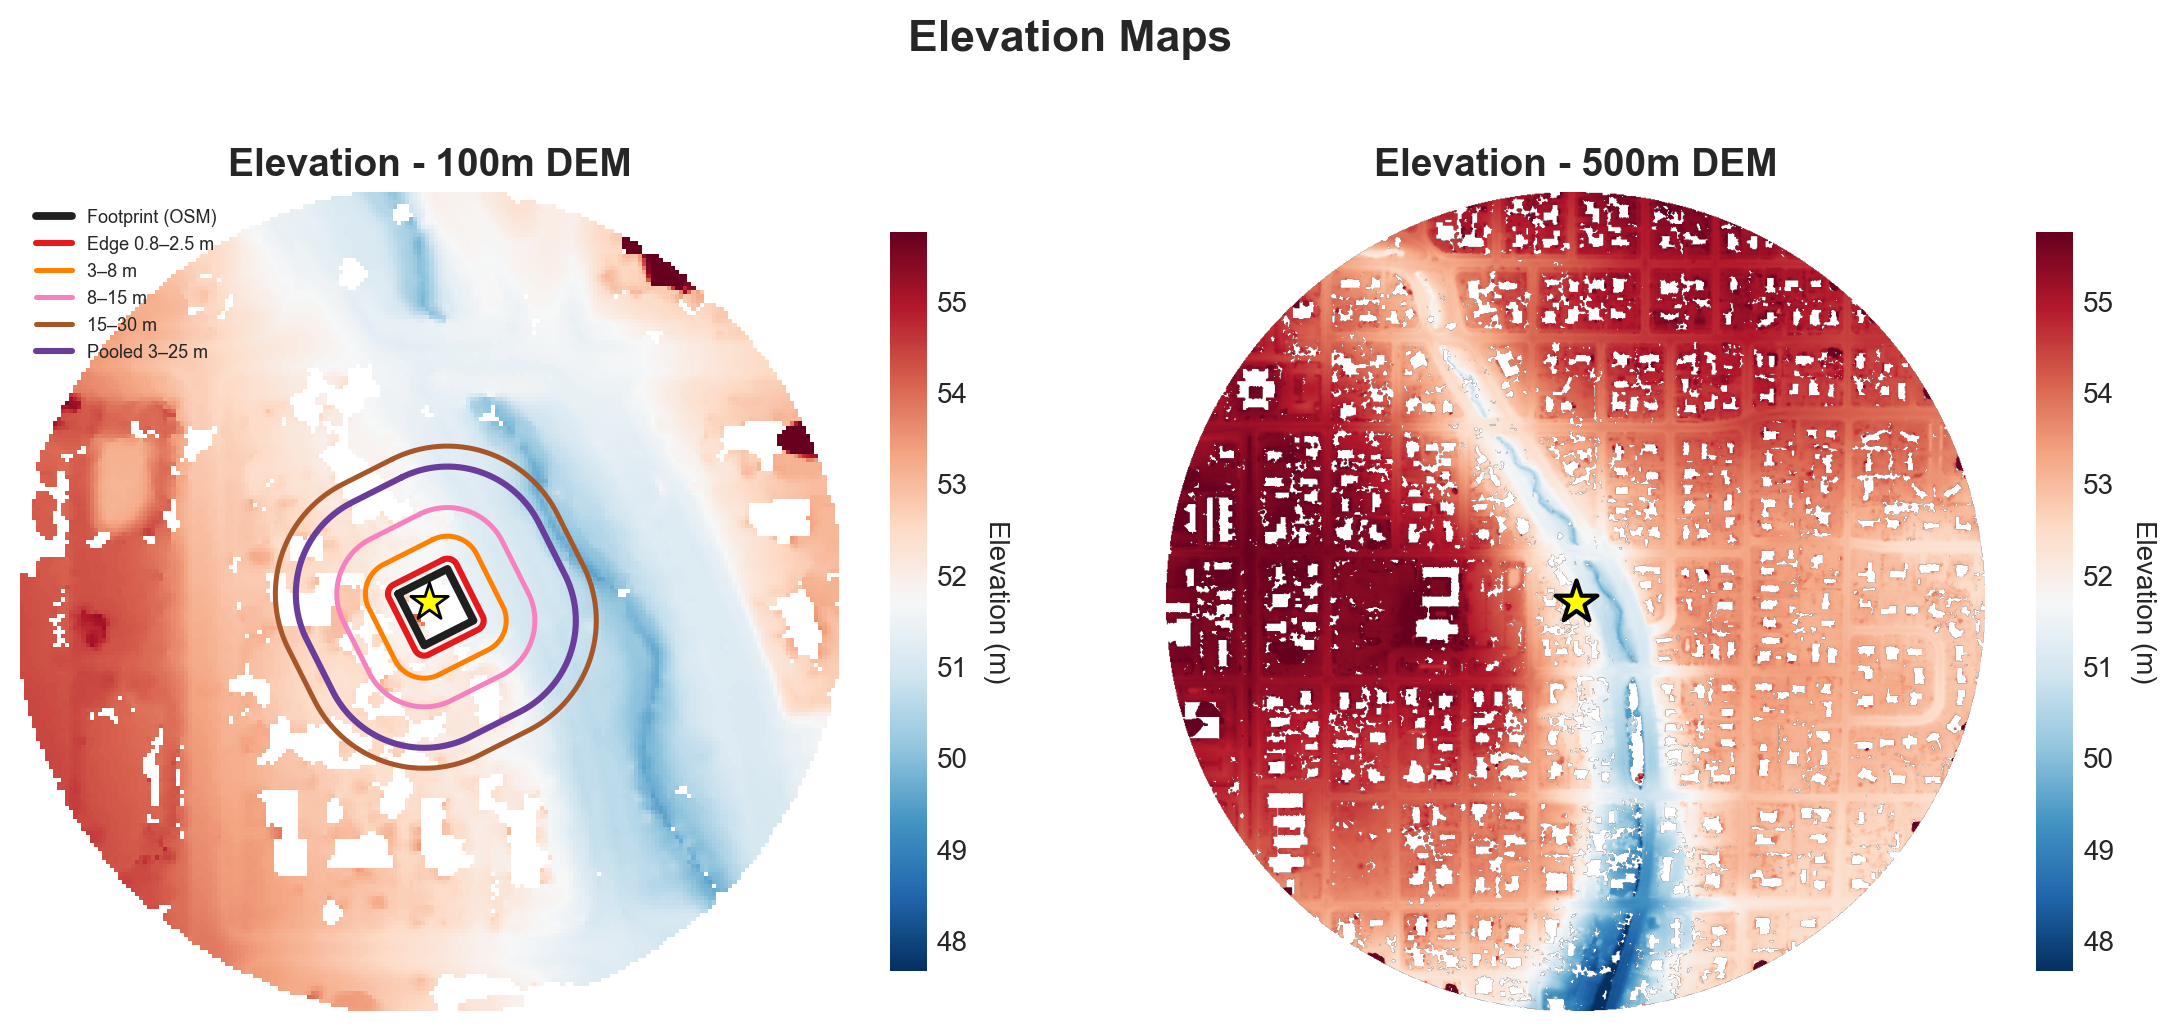

Checking: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run/figure2_slope.png  ->  exists = True


#### Slope Analysis

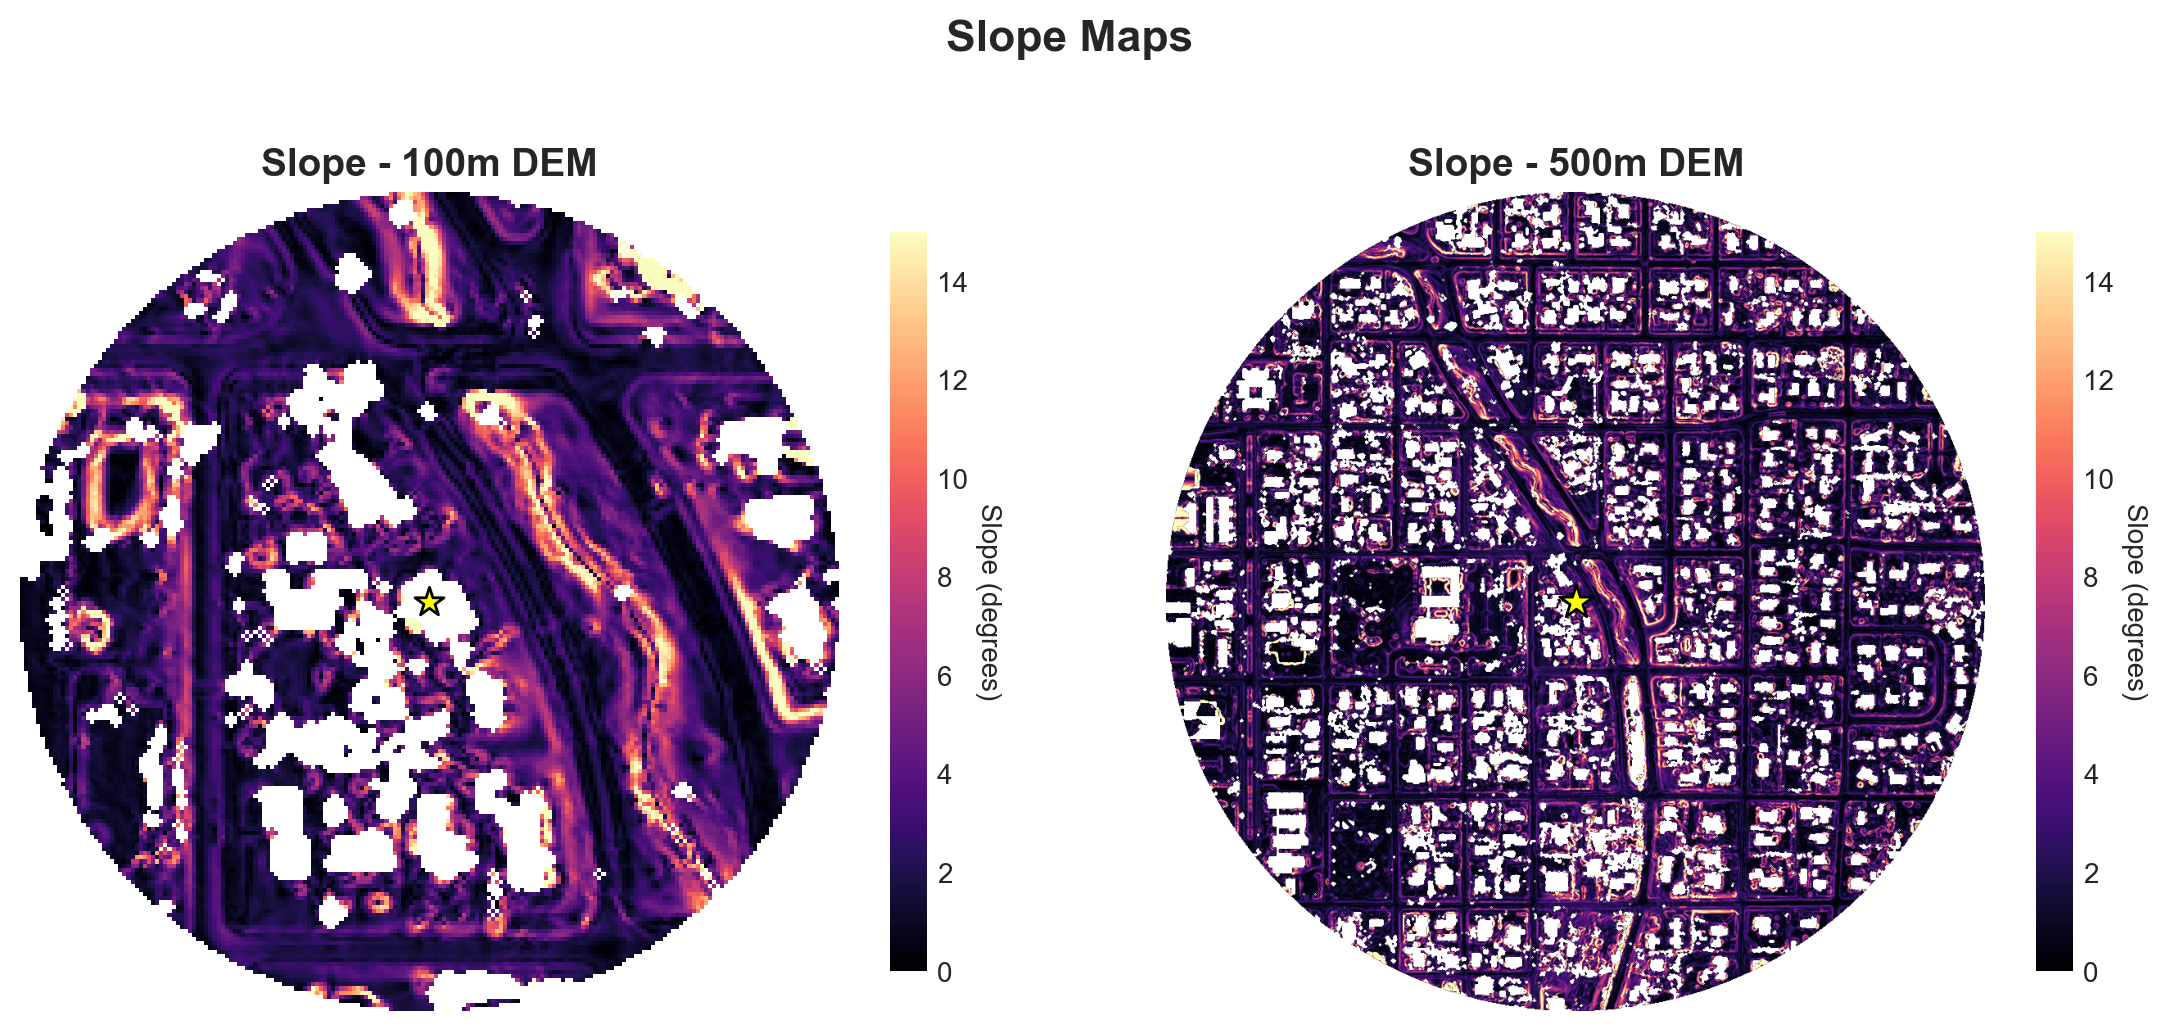

Checking: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run/figure3_aspect.png  ->  exists = True


#### Aspect (Drainage Direction)

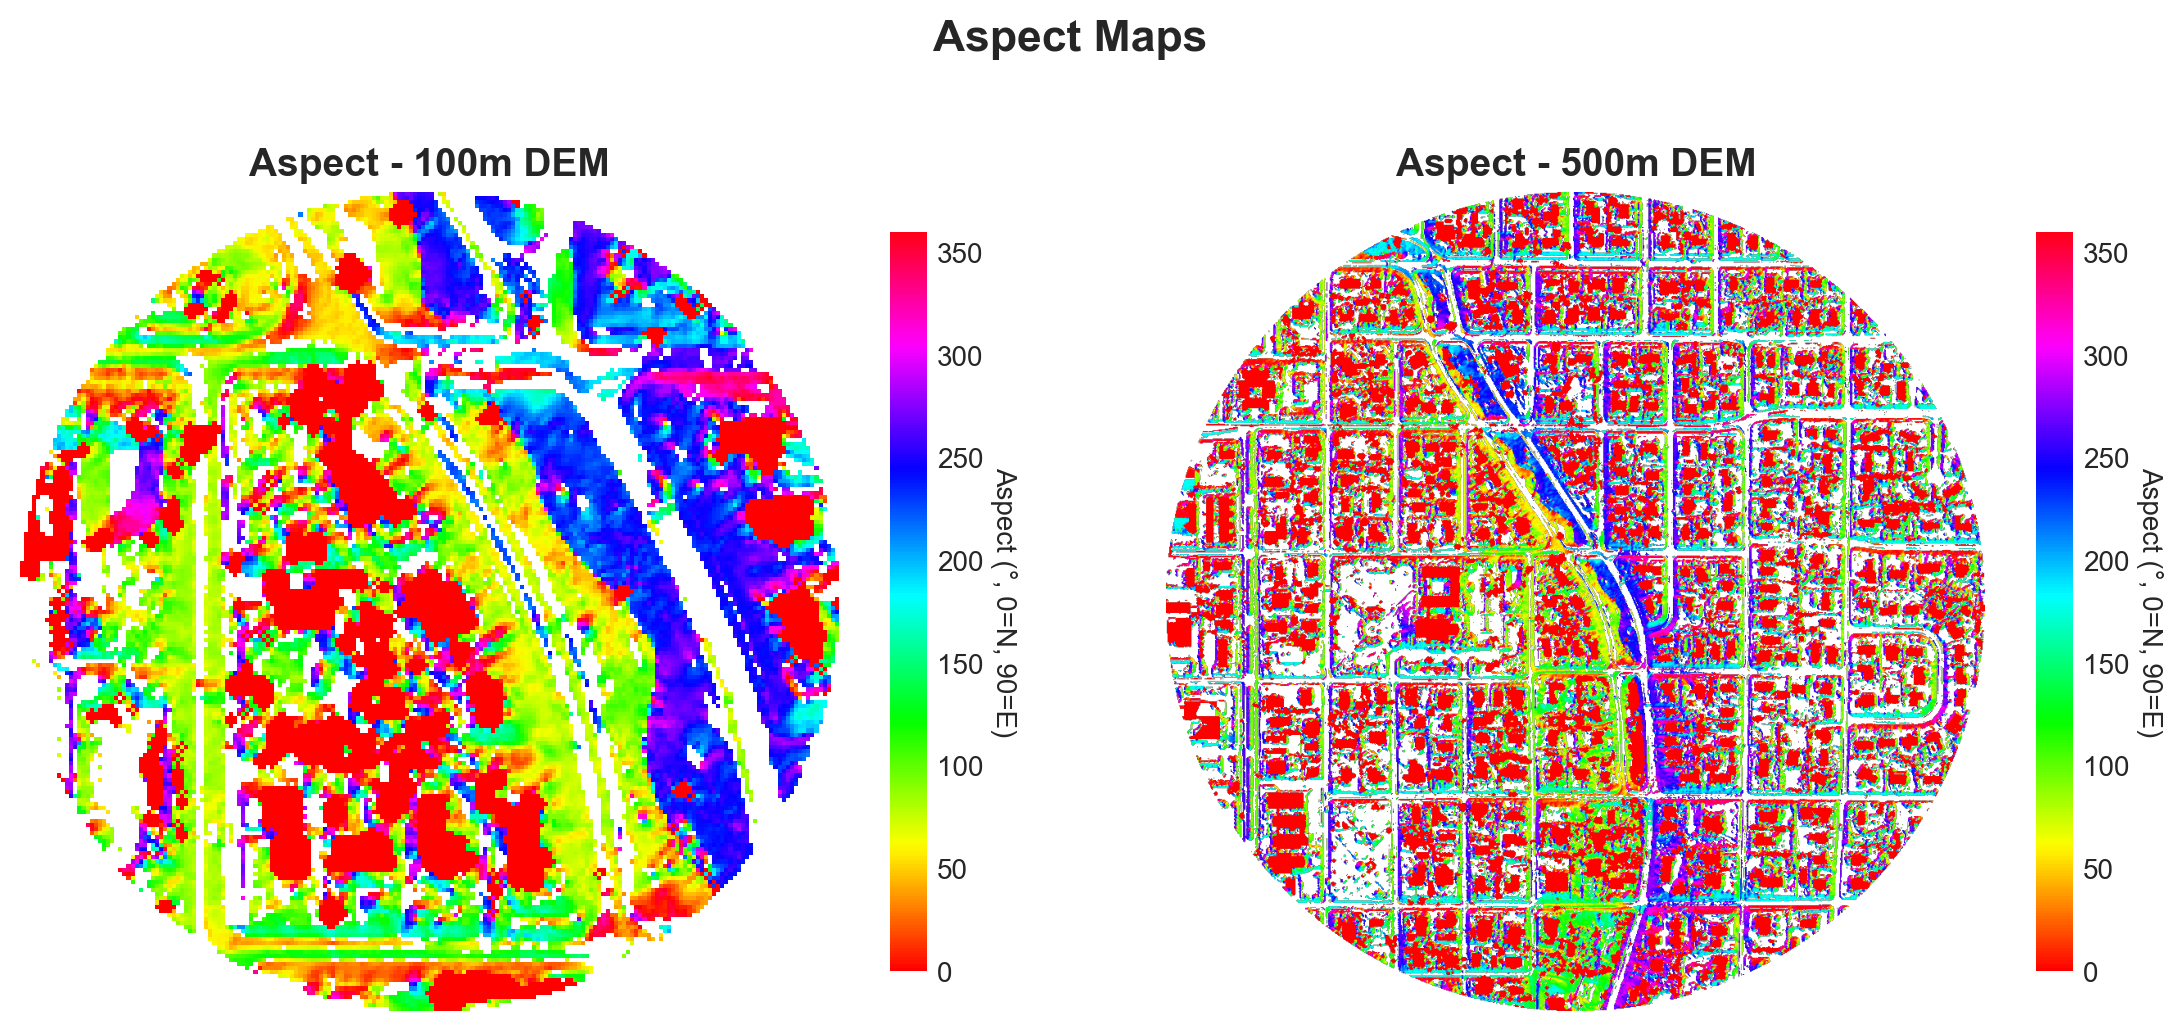

Checking: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run/figure4_terrain_and_hist.png  ->  exists = True


#### Terrain Classification & Distribution

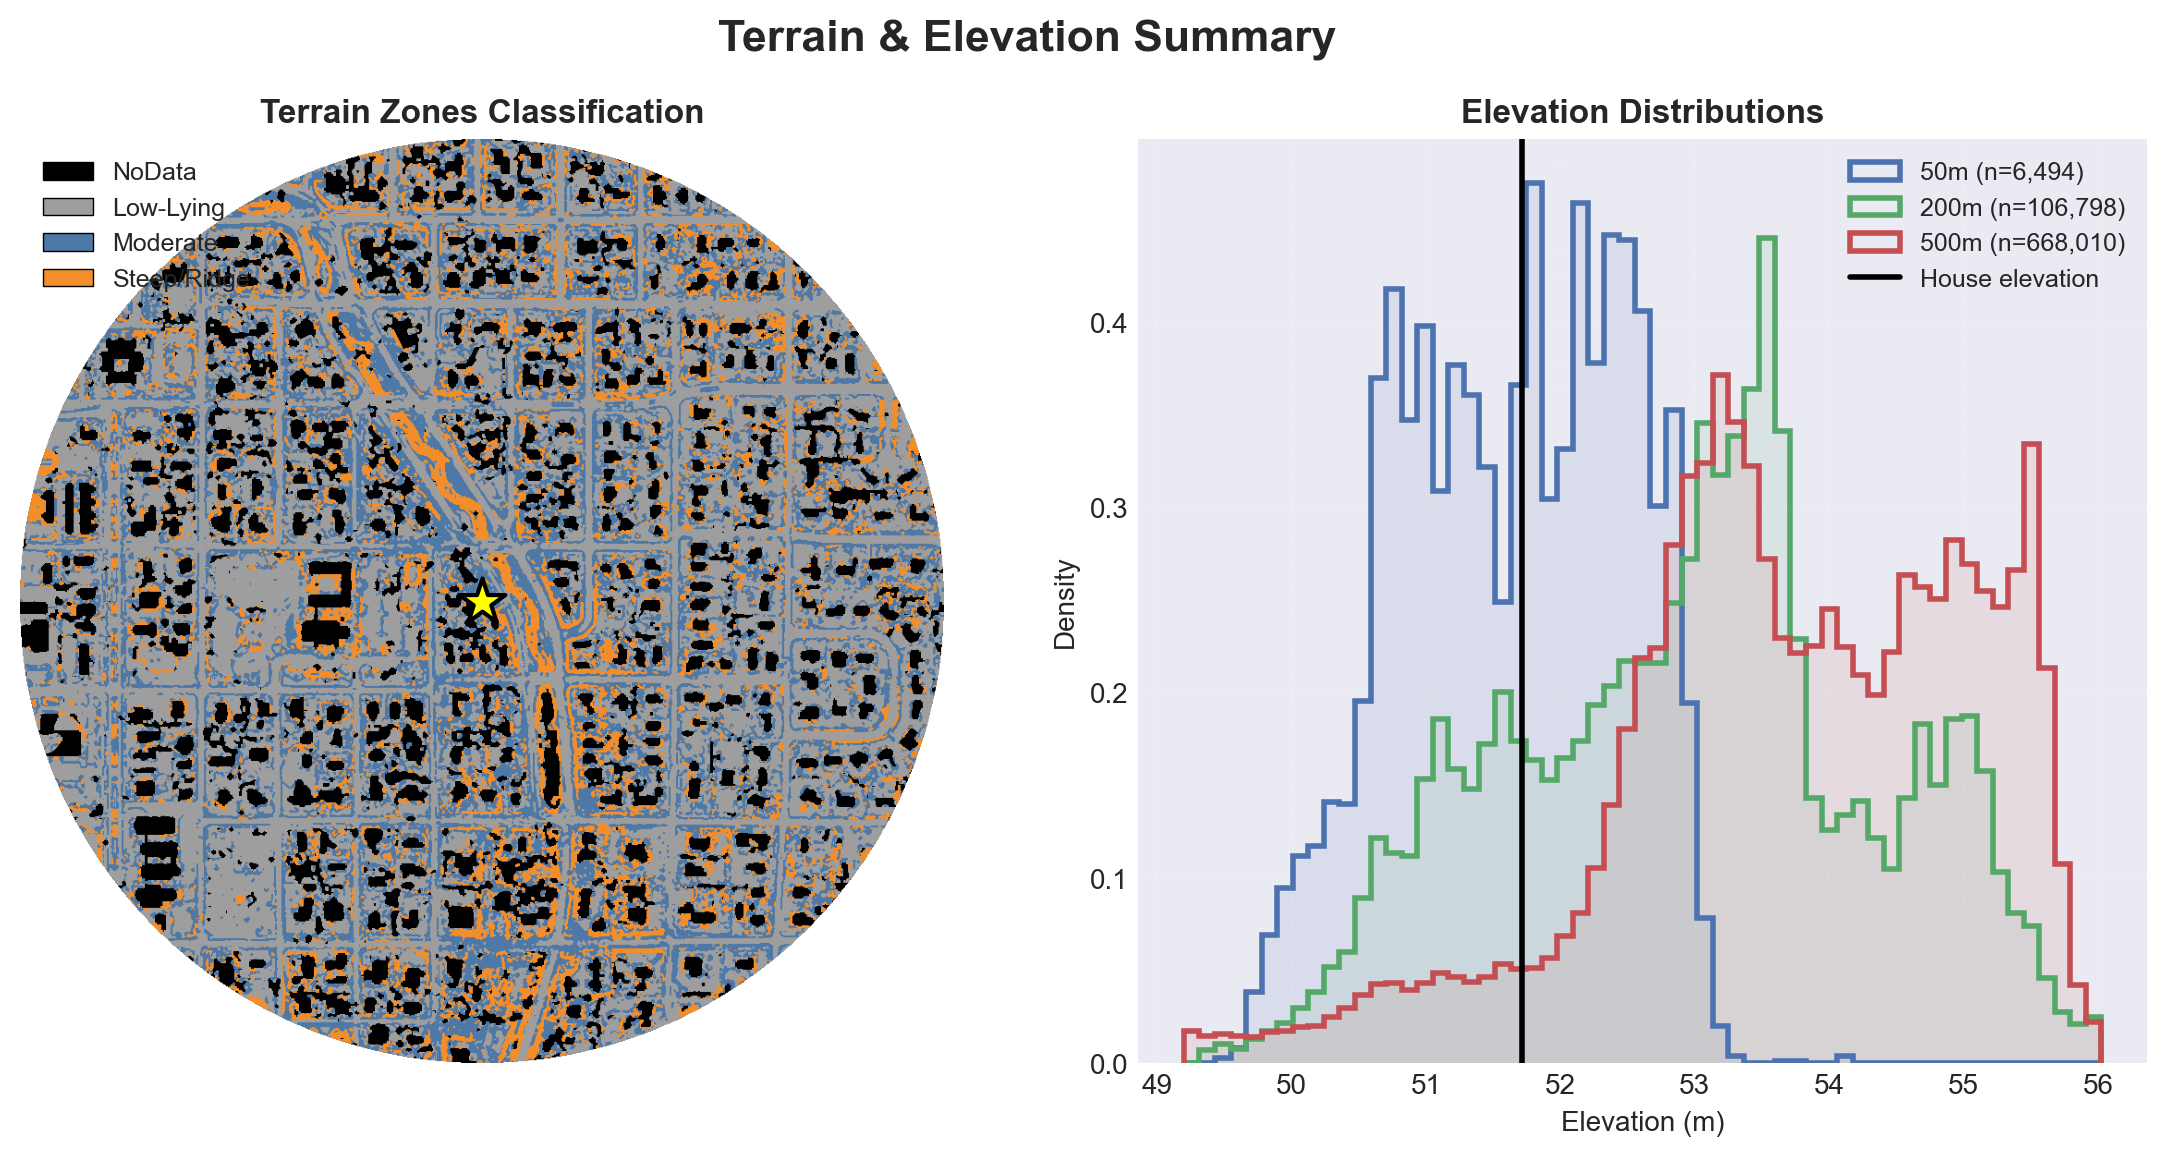

Checking: /Users/yaoyiyang/Desktop/Uchicago-elevation/tests/scripts/outputs/demo_run/figure_terrain_risk_map.png  ->  exists = True


#### Global Composite Risk Map

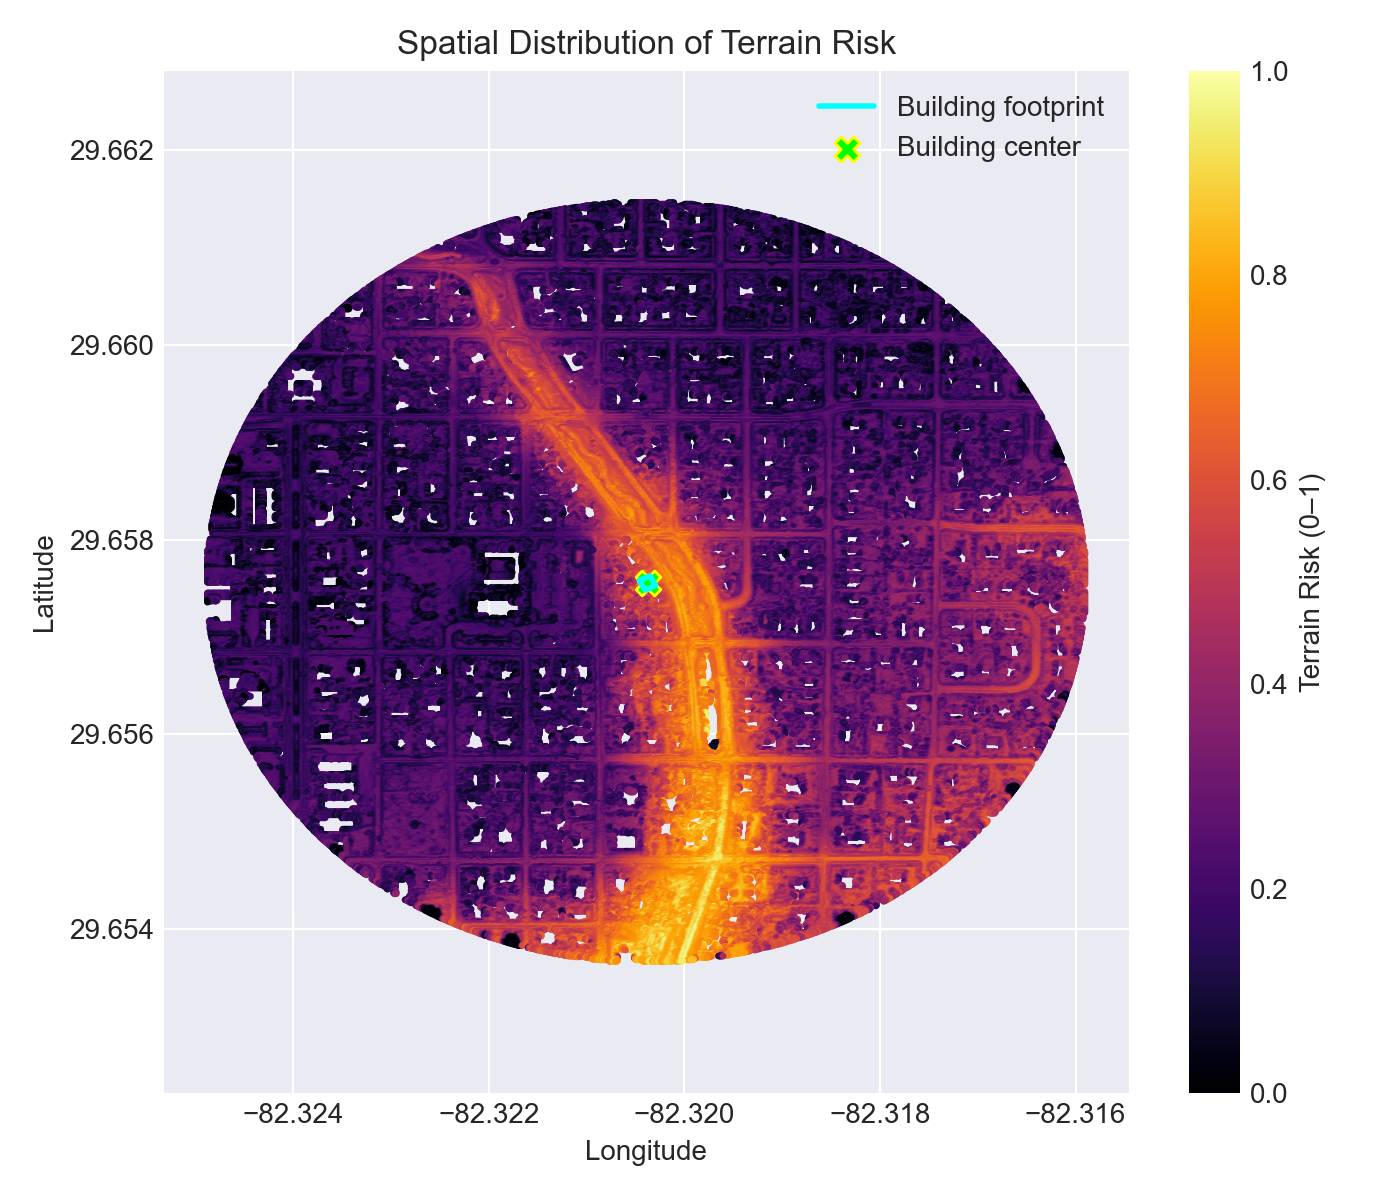

In [28]:
from pathlib import Path
from IPython.display import Markdown, display, Image

display(Markdown("### 🗺️ **Generated Maps & Visualizations**"))

output_dir = Path(results.get('outputs_dir', results.get('run_root_dir', '.')))
print("Using output_dir:", output_dir.resolve())

visualizations = [
    ('figure1_elevation.png', 'Elevation Map with Building Location'),
    ('figure2_slope.png', 'Slope Analysis'),
    ('figure3_aspect.png', 'Aspect (Drainage Direction)'),
    ('figure4_terrain_and_hist.png', 'Terrain Classification & Distribution'),
    ('figure_terrain_risk_map.png', 'Global Composite Risk Map')
]

for img_file, title in visualizations:
    img_path = output_dir / img_file
    print(f"Checking: {img_path.resolve()}  ->  exists = {img_path.exists()}")
    
    if img_path.exists():
        # 小标题 + 图片
        display(Markdown(f"#### {title}"))
        display(Image(filename=str(img_path)))
    else:
        display(Markdown(f"#### {title}"))
        display(Markdown(f"> ⚠️ `{img_file}` not found at `{img_path}`"))


## 8. 3D Terrain Visualization

Interactive 3D view of the terrain around the property.

## 9. Terrain Risk Score Breakdown

Detailed explanation of how the composite terrain risk score was calculated.

In [12]:
# Display risk score components
display(Markdown("### ⚠️ **Terrain Risk Score Components**"))

# Risk calculation parameters
risk_components = pd.DataFrame([
    ["Global Elevation", 0.50, "Position in 500m elevation distribution"],
    ["Local Depression", 0.20, "Elevation vs. local average (10m window)"],
    ["Slope", 0.20, "Terrain steepness (affects drainage speed)"],
    ["Flow Convergence", 0.10, "Water accumulation patterns"]
], columns=["Component", "Weight", "Description"])

display(risk_components.style.bar(subset=['Weight'], color='#ff9999', vmin=0, vmax=1))

# Create risk score visualization
if 'terrain_risk_score' in results:
    risk_score = results['terrain_risk_score']
    risk_pct = results.get('risk_percentile', 50)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Risk gauge
    theta = np.linspace(np.pi, 0, 100)
    r = np.ones_like(theta)
    
    # Color gradient for risk levels
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, 100))
    
    for i in range(len(theta)-1):
        ax1.fill_between([theta[i], theta[i+1]], 0, 1, color=colors[i])
    
    # Add needle for current score
    angle = np.pi * (1 - risk_score)
    ax1.arrow(0, 0, 0.9*np.cos(angle), 0.9*np.sin(angle), 
             head_width=0.05, head_length=0.1, fc='black', ec='black')
    
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-0.2, 1.2)
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title(f'Risk Score: {risk_score:.3f}', fontsize=14, fontweight='bold')
    ax1.text(0, -0.15, f'Percentile: {risk_pct:.1f}%', ha='center', fontsize=10)
    
    # Risk distribution
    np.random.seed(42)
    sample_scores = np.random.beta(2, 5, 1000)  # Simulated distribution
    ax2.hist(sample_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.axvline(risk_score, color='red', linestyle='--', linewidth=2, label=f'This Property: {risk_score:.3f}')
    ax2.set_xlabel('Terrain Risk Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Risk Score Distribution (Regional Context)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Terrain risk score not computed")

### ⚠️ **Terrain Risk Score Components**

,Component,Weight,Description
0,Global Elevation,0.500000,Position in 500m elevation distribution
1,Local Depression,0.200000,Elevation vs. local average (10m window)
2,Slope,0.200000,Terrain steepness (affects drainage speed)
3,Flow Convergence,0.100000,Water accumulation patterns


## 10. Natural Language Report

In [15]:
# Display the narrative report
display(Markdown("### 📝 **Narrative Report**"))

narrative_path = output_dir / 'narrative.txt'
if narrative_path.exists():
    with open(narrative_path, 'r') as f:
        narrative = f.read()
    
    # Display in a styled box
    display(Markdown(f"""
<div padding: 20px; border-left: 4px solid #2E86AB; border-radius: 5px;">

{narrative}

</div>
"""))
else:
    print("Narrative report not generated")

### 📝 **Narrative Report**


<div padding: 20px; border-left: 4px solid #2E86AB; border-radius: 5px;">

At 500 m, the home sits -2.013 m relative to the area median elevation. Within 10 m, median slope is ~2.2°, indicating flat-to-gentle. Nearby ground tilts toward N (~1°), a likely drainage direction. Local curvature suggests a slightly convex surface (ridge-like). Median slope by scale — 50 m: 3.0°; 200 m: 2.4°; 500 m: 1.9°. At 500 m, ~25% of surrounding surfaces point downslope toward the home; dominant downslope direction is N (~7°).

The terrain risk model estimates a terrain risk score of 0.617 for this location, which ranks at the 90.9th percentile across the entire area, meaning it is higher and less flood-prone than about 9.1% of the terrain in this DEM region.


</div>
